# Feature Engineering & Master Dataframe Erstellung

#### 1. Übersicht & Zielsetzung
Ziel der Pipelines im Notebook ist es, transaktionale Buchungsdaten (Sessions, Flüge, Hotels) auf Ebene der einzelnen Nutzer (user_id) zu aggregieren und mit demografischen Stammdaten zu verknüpfen. Das Endergebnis ist ein Master-Dataset (df_master), das als Grundlage für Machine Learning und Analysen dient.

### 2. Einzelne Pipeline-Schritte
Zusammenführung der Rohdaten (Merging)
Die Einzel-Dataframes werden über die gemeinsame Kennung trip_id mittels Left Join an die Session-Daten angebunden:

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
#========Daten einlesen ============

df_users = pd.read_csv("../data/preprocessed/users_cleaned.csv")
df_sessions = pd.read_csv("../data/preprocessed/sessions_cleaned.csv")
df_hotels = pd.read_csv("../data/preprocessed/hotels_cleaned.csv")
df_flights = pd.read_csv("../data/preprocessed/flights_cleaned.csv")


In [4]:
df_sessions.columns

Index(['session_id', 'user_id', 'trip_id', 'session_start', 'session_end',
       'flight_discount', 'hotel_discount', 'flight_discount_amount',
       'hotel_discount_amount', 'flight_booked', 'hotel_booked', 'page_clicks',
       'cancellation', 'duration_session'],
      dtype='str')

In [5]:
import numpy as np
import pandas as pd

# 1. Zusammenführung der Transaktionsdaten
df_merged = df_sessions.merge(df_hotels, on="trip_id", how="left").merge(
    df_flights, on="trip_id", how="left"
)

# Stornierungs-Spalte als Boolean bereinigen
df_merged["cancellation"] = (
    df_merged["cancellation"].fillna(False).astype(bool)
)




# 2. Kosten pro Transaktion berechnen (unter Berücksichtigung von Stornierungen & Rabatten)
# Flugkosten: 0 wenn storniert oder nicht gebucht, sonst base_fare * (1 - Rabatt)
df_merged["flight_cost"] = np.where(
    (df_merged["flight_booked"] == True) & (~df_merged["cancellation"]),
    df_merged["base_fare_usd"] * (1 - df_merged["flight_discount_amount"]),
    0.0,
)

# Hotelkosten: 0 wenn storniert oder nicht gebucht, sonst Nächte * Zimmer * Preis * (1 - Rabatt)
df_merged["hotel_cost"] = np.where(
    (df_merged["hotel_booked"] == True) & (~df_merged["cancellation"]),
    df_merged["nights"]
    * df_merged["rooms"].fillna(0)
    * df_merged["hotel_per_room_usd"].fillna(0)
    * (1 - df_merged["hotel_discount_amount"]),
    0.0,
)


# 3. Hilfsspalten für nicht-stornierte Buchungen & Kennzahlen
df_merged["flight_booked_valid"] = df_merged["flight_booked"] & (
    ~df_merged["cancellation"]
)
df_merged["hotel_booked_valid"] = df_merged["hotel_booked"] & (
    ~df_merged["cancellation"]
)

if "checked_bags" in df_merged.columns:
    df_merged["checked_bags_valid"] = df_merged["checked_bags"].where(
        ~df_merged["cancellation"]
    )
else:
    df_merged["checked_bags_valid"] = np.nan




# 4. Aggregation auf user_id-Ebene
user_features = (
    df_merged.groupby("user_id")
    .agg(
        total_sessions=("session_id", "count"),
        total_trips=("trip_id", "nunique"),
        # Buchungs-Anzahlen (Gesamt vs. Erfolgreich)
        flight_booked_cnt=("flight_booked", "sum"),
        flight_booked_valid_cnt=("flight_booked_valid", "sum"),
        hotel_booked_cnt=("hotel_booked", "sum"),
        hotel_booked_valid_cnt=("hotel_booked_valid", "sum"),
        # UMSATZ / KOSTEN
        total_flights_cost=("flight_cost", "sum"),
        total_hotels_cost=("hotel_cost", "sum"),
        # Durchschnitts-Metriken (gerundet auf 2 Nachkommastellen)
        avg_checked_bags=(
            "checked_bags_valid",
            lambda x: round(x.mean(), 2),
        ),
        avg_hotel_nights=("nights", lambda x: round(x.mean(), 2)),
        # Rabattnutzung
        discount_flight_uses=("flight_discount", "sum"),
        discount_hotel_uses=("hotel_discount", "sum"),
        # Stornierungs-Features
        total_cancellations=("cancellation", "sum"),
        cancellation_rate=("cancellation", "mean"),
        # Interaktionen
        avg_page_clicks=("page_clicks", "mean"),
        
    )
    .reset_index()
)


# 5. Demografische Daten verknüpfen & Master Dataframe erstellen
df_users["birthdate"] = pd.to_datetime(df_users["birthdate"])
df_users["age"] = (
    (pd.Timestamp.now() - df_users["birthdate"]).dt.days // 365.25
).astype("Int64")

df_master = df_users.merge(user_features, on="user_id", how="left")

# Fehlende Werte in den aggregierten Features mit 0 auffüllen
feature_cols = user_features.columns.drop("user_id")
df_master[feature_cols] = df_master[feature_cols].fillna(0)

In [6]:
df_master

,user_id,birthdate,gender,married,has_children,home_country,home_city,home_airport,home_airport_lat,home_airport_lon,...,hotel_booked_valid_cnt,total_flights_cost,total_hotels_cost,avg_checked_bags,avg_hotel_nights,discount_flight_uses,discount_hotel_uses,total_cancellations,cancellation_rate,avg_page_clicks
0,94883,1972-03-16,F,True,False,usa,kansas city,MCI,39.297,-94.714,...,2,5354.8600,130.00,1.00,0.50,1,2,0,0.000000,8.333333
1,101486,1972-12-07,F,True,True,usa,tacoma,TCM,47.138,-122.476,...,4,2887.0515,6307.00,1.33,7.60,5,1,1,0.076923,26.153846
2,101961,1980-09-14,F,True,False,usa,boston,BOS,42.364,-71.005,...,7,1924.2330,2954.00,0.50,3.14,3,1,0,0.000000,18.166667
3,106907,1978-11-17,F,True,True,usa,miami,TNT,25.862,-80.897,...,3,14067.5700,6442.20,3.00,8.50,2,2,1,0.071429,26.285714
4,118043,1972-05-04,F,False,True,usa,los angeles,LAX,33.942,-118.408,...,4,2398.8000,5616.45,0.75,5.50,4,5,1,0.076923,16.153846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5777,780167,1974-06-08,F,True,True,usa,los angeles,LAX,33.942,-118.408,...,1,1122.1060,220.00,0.00,1.00,2,1,0,0.000000,15.500000
5778,785186,1979-06-03,F,True,True,usa,little rock,LIT,34.729,-92.224,...,2,353.3500,184.00,0.00,0.50,1,2,0,0.000000,21.625000
5779,792549,1978-01-25,F,False,False,usa,kansas city,MCI,39.297,-94.714,...,1,1039.1700,144.00,0.50,4.00,1,0,0,0.000000,14.250000
5780,811077,1979-02-22,F,True,True,usa,knoxville,TYS,35.812,-83.993,...,1,579.7900,852.00,0.00,6.00,2,1,0,0.000000,13.125000


In [7]:
df_master.columns

Index(['user_id', 'birthdate', 'gender', 'married', 'has_children',
       'home_country', 'home_city', 'home_airport', 'home_airport_lat',
       'home_airport_lon', 'sign_up_date', 'age', 'total_sessions',
       'total_trips', 'flight_booked_cnt', 'flight_booked_valid_cnt',
       'hotel_booked_cnt', 'hotel_booked_valid_cnt', 'total_flights_cost',
       'total_hotels_cost', 'avg_checked_bags', 'avg_hotel_nights',
       'discount_flight_uses', 'discount_hotel_uses', 'total_cancellations',
       'cancellation_rate', 'avg_page_clicks'],
      dtype='str')

In [8]:
df_master.drop(["birthdate", "home_airport_lat","home_airport_lon","sign_up_date","avg_page_clicks"], axis=1, inplace=True)

In [9]:
df_master["total_flights_cost"] = round(df_master["total_flights_cost"], 2)
df_master["total_hotels_cost"] = round(df_master["total_hotels_cost"], 2)
df_master["cancellation_rate"] = round(df_master["cancellation_rate"], 2)

In [10]:
df_master

,user_id,gender,married,has_children,home_country,home_city,home_airport,age,total_sessions,total_trips,...,hotel_booked_cnt,hotel_booked_valid_cnt,total_flights_cost,total_hotels_cost,avg_checked_bags,avg_hotel_nights,discount_flight_uses,discount_hotel_uses,total_cancellations,cancellation_rate
0,94883,F,True,False,usa,kansas city,MCI,54,12,4,...,2,2,5354.86,130.00,1.00,0.50,1,2,0,0.00
1,101486,F,True,True,usa,tacoma,TCM,53,13,5,...,5,4,2887.05,6307.00,1.33,7.60,5,1,1,0.08
2,101961,F,True,False,usa,boston,BOS,46,12,8,...,7,7,1924.23,2954.00,0.50,3.14,3,1,0,0.00
3,106907,F,True,True,usa,miami,TNT,47,14,4,...,4,3,14067.57,6442.20,3.00,8.50,2,2,1,0.07
4,118043,F,False,True,usa,los angeles,LAX,54,13,7,...,5,4,2398.80,5616.45,0.75,5.50,4,5,1,0.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5777,780167,F,True,True,usa,los angeles,LAX,52,8,3,...,1,1,1122.11,220.00,0.00,1.00,2,1,0,0.00
5778,785186,F,True,True,usa,little rock,LIT,47,8,3,...,2,2,353.35,184.00,0.00,0.50,1,2,0,0.00
5779,792549,F,False,False,usa,kansas city,MCI,48,8,5,...,1,1,1039.17,144.00,0.50,4.00,1,0,0,0.00
5780,811077,F,True,True,usa,knoxville,TYS,47,8,2,...,1,1,579.79,852.00,0.00,6.00,2,1,0,0.00


In [11]:
# speichern der Master-Features in einer CSV-Datei
df_master.to_csv("../data/preprocessed/master_features.csv", index=False)

# Explorative Datenanalyse (EDA) & Visualisierung

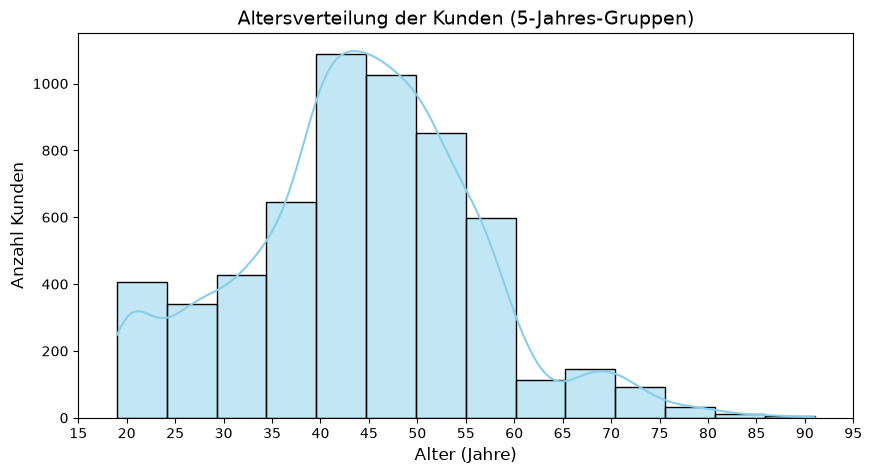

In [12]:
plt.figure(figsize=(10, 5))

# Histogramm mit 5-Jahres-Bins
sns.histplot(
    data=df_master,
    x="age",
    binwidth=5,
    kde=True,
    color="skyblue",
    edgecolor="black",
)

plt.title("Altersverteilung der Kunden (5-Jahres-Gruppen)", fontsize=14)
plt.xlabel("Alter (Jahre)", fontsize=12)
plt.ylabel("Anzahl Kunden", fontsize=12)

# X-Achse in 5er-Schritten beschriften
min_age = int(df_master["age"].min())
max_age = int(df_master["age"].max())
plt.xticks(range(min_age - (min_age % 5), max_age + 6, 5))

plt.savefig("../report/Altersverteilung_der_Kunden.png", dpi=300, bbox_inches="tight")

plt.show()

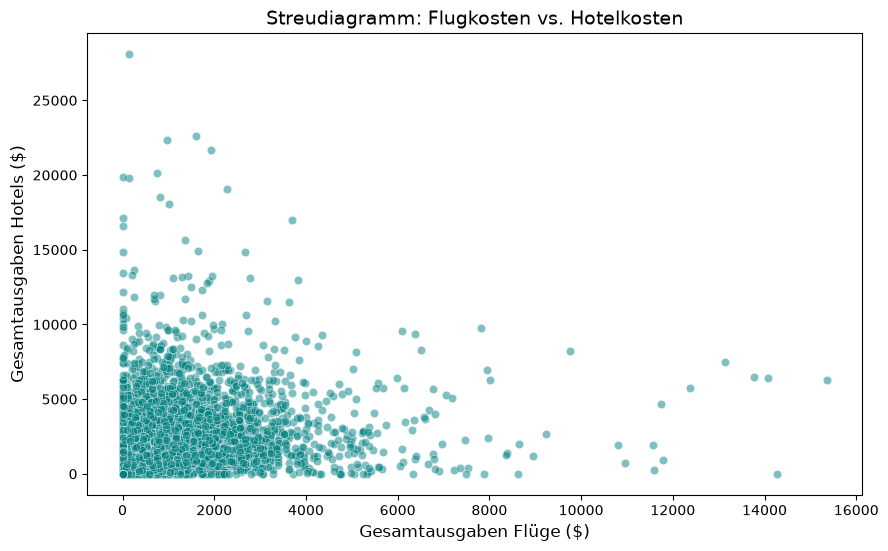

In [13]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_master,
    x="total_flights_cost",
    y="total_hotels_cost",
    alpha=0.5,
    color="teal",
)

plt.title("Streudiagramm: Flugkosten vs. Hotelkosten", fontsize=14)
plt.xlabel("Gesamtausgaben Flüge ($)", fontsize=12)
plt.ylabel("Gesamtausgaben Hotels ($)", fontsize=12)
plt.savefig("../report/Flugkosten_vs_Hotelkosten.png", dpi=300, bbox_inches="tight")
plt.show()

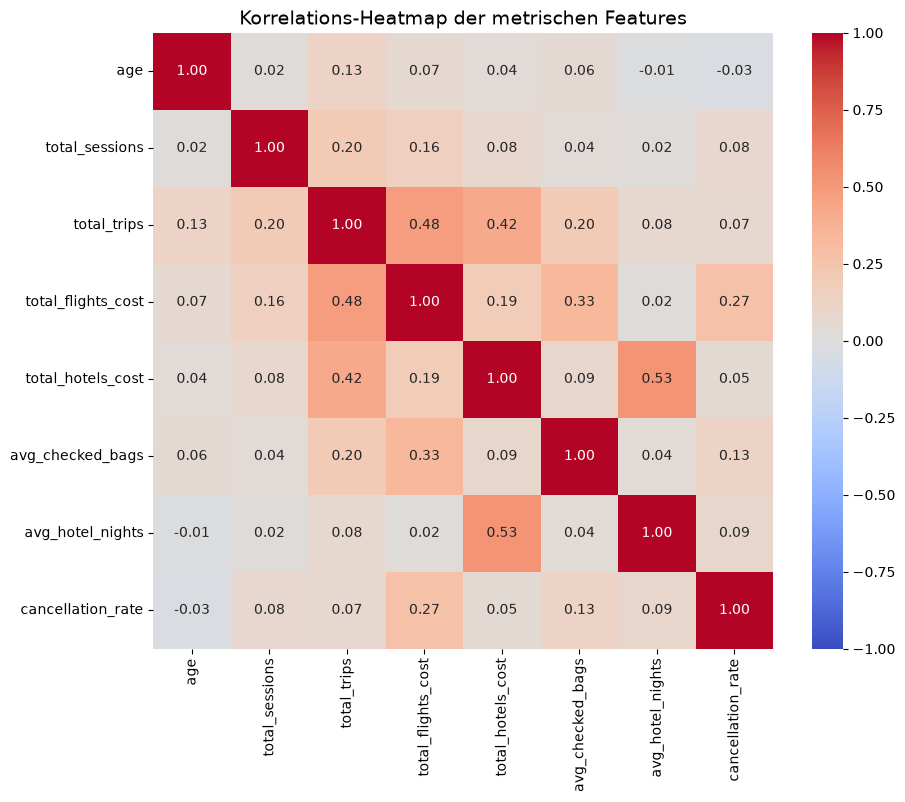

In [19]:
# Nur die gewünschten Spalten – exakt wie im Bild
num_cols = ['age', 'total_sessions', 'total_trips', 'total_flights_cost',
            'total_hotels_cost', 'avg_checked_bags', 'avg_hotel_nights',
            'cancellation_rate']

plt.figure(figsize=(10, 8))
corr = df_master[num_cols].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Korrelations-Heatmap der metrischen Features", fontsize=14)
plt.savefig("../report/Korrelations_Heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

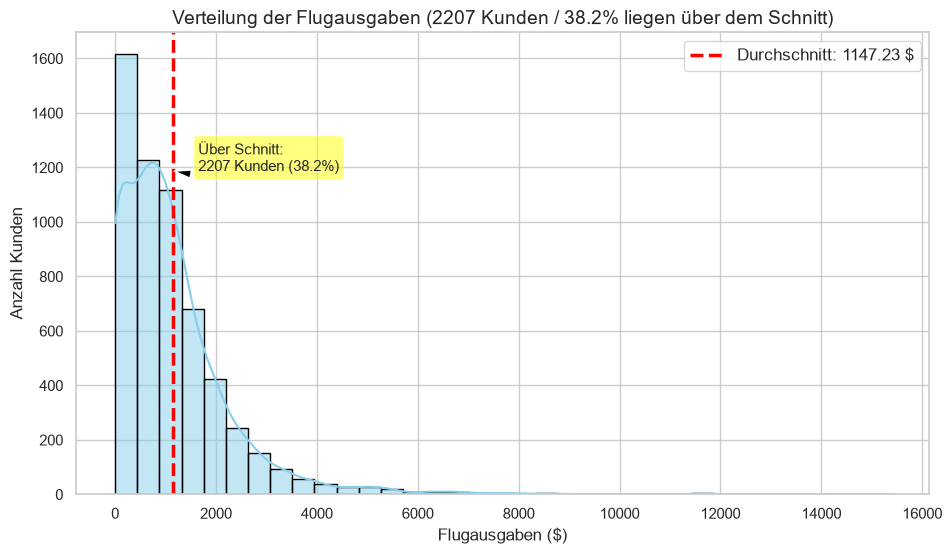

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Durchschnitt und Anteile berechnen
mean_flight_cost = df_master["total_flights_cost"].mean()
above_avg = df_master["total_flights_cost"] > mean_flight_cost
count_above = above_avg.sum()
pct_above = (count_above / len(df_master)) * 100

plt.figure(figsize=(11, 6))

# 2. Histogramm der Flugkosten zeichnen
sns.histplot(
    data=df_master,
    x="total_flights_cost",
    bins=35,
    kde=True,
    color="skyblue",
    edgecolor="black",
)

# 3. Rote gestrichelte Linie für den Durchschnitt einfügen
plt.axvline(
    mean_flight_cost,
    color="red",
    linestyle="--",
    linewidth=2.5,
    label=f"Durchschnitt: {mean_flight_cost:.2f} $",
)

# 4. Optische Hervorhebung & Beschriftung
plt.title(
    f"Verteilung der Flugausgaben ({count_above} Kunden / {pct_above:.1f}% liegen über dem Schnitt)",
    fontsize=14,
)
plt.xlabel("Flugausgaben ($)", fontsize=12)
plt.ylabel("Anzahl Kunden", fontsize=12)
plt.legend(fontsize=12)

# Text-Annotation im Plot platzieren
plt.annotate(
    f"Über Schnitt:\n{count_above} Kunden ({pct_above:.1f}%)",
    xy=(mean_flight_cost, plt.gca().get_ylim()[1] * 0.7),
    xytext=(mean_flight_cost + 500, plt.gca().get_ylim()[1] * 0.7),
    arrowprops=dict(facecolor="black", shrink=0.05, width=1, headwidth=6),
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5),
)
plt.savefig("../report/Verteilung_der_Flugkosten.png", dpi=300, bbox_inches="tight")
plt.show()

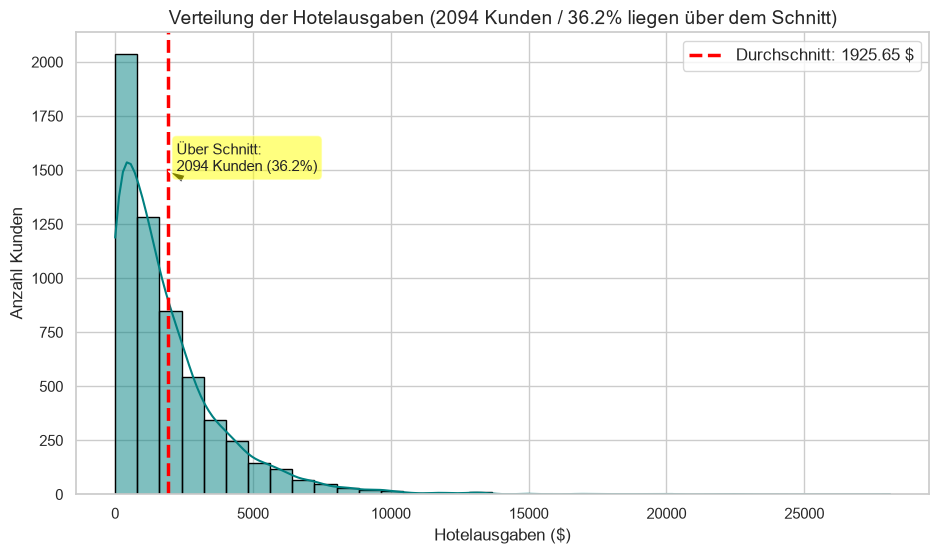

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Durchschnitt und Anteile berechnen
mean_hotel_cost = df_master["total_hotels_cost"].mean()
above_avg = df_master["total_hotels_cost"] > mean_hotel_cost
count_above = above_avg.sum()
pct_above = (count_above / len(df_master)) * 100

plt.figure(figsize=(11, 6))

# 2. Histogramm der Hotelkosten zeichnen
sns.histplot(
    data=df_master,
    x="total_hotels_cost",
    bins=35,
    kde=True,
    color="teal",
    edgecolor="black",
)

# 3. Rote gestrichelte Linie für den Durchschnitt einfügen
plt.axvline(
    mean_hotel_cost,
    color="red",
    linestyle="--",
    linewidth=2.5,
    label=f"Durchschnitt: {mean_hotel_cost:.2f} $",
)

# 4. Optische Hervorhebung & Beschriftung
plt.title(
    f"Verteilung der Hotelausgaben ({count_above} Kunden / {pct_above:.1f}% liegen über dem Schnitt)",
    fontsize=14,
)
plt.xlabel("Hotelausgaben ($)", fontsize=12)
plt.ylabel("Anzahl Kunden", fontsize=12)
plt.legend(fontsize=12)

# Text-Annotation im Plot platzieren
plt.annotate(
    f"Über Schnitt:\n{count_above} Kunden ({pct_above:.1f}%)",
    xy=(mean_hotel_cost, plt.gca().get_ylim()[1] * 0.7),
    xytext=(mean_hotel_cost + 300, plt.gca().get_ylim()[1] * 0.7),
    arrowprops=dict(facecolor="black", shrink=0.05, width=1, headwidth=6),
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5),
)
plt.savefig("../report/Verteilung_der_Hotelausgaben.png", dpi=300, bbox_inches="tight")

plt.show()

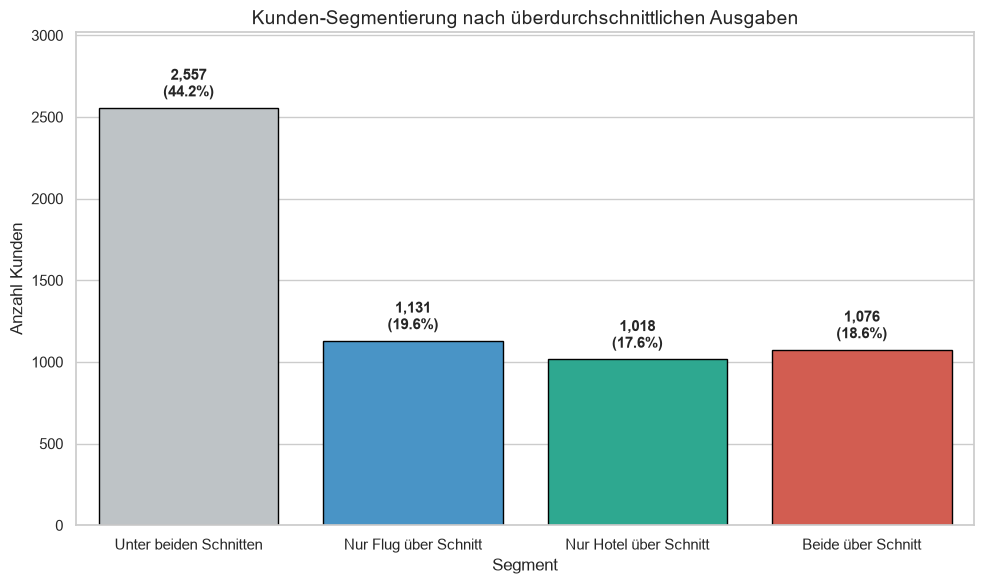

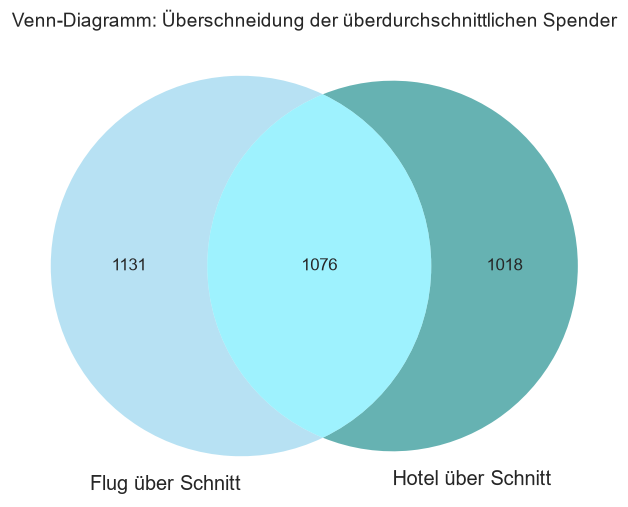

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Durchschnitte berechnen
mean_flight = df_master["total_flights_cost"].mean()
mean_hotel = df_master["total_hotels_cost"].mean()

# 2. Boolesche Masken für Ausgaben über dem Schnitt
above_flight = df_master["total_flights_cost"] > mean_flight
above_hotel = df_master["total_hotels_cost"] > mean_hotel


# 3. Zuordnung der Kunden zu 4 Segmenten
def categorize_spender(row):
    f = row["total_flights_cost"] > mean_flight
    h = row["total_hotels_cost"] > mean_hotel
    if f and h:
        return "Beide über Schnitt"
    elif f and not h:
        return "Nur Flug über Schnitt"
    elif not f and h:
        return "Nur Hotel über Schnitt"
    else:
        return "Unter beiden Schnitten"


df_master["spending_segment"] = df_master.apply(categorize_spender, axis=1)

# Auszählung der Segmente
segment_order = [
    "Unter beiden Schnitten",
    "Nur Flug über Schnitt",
    "Nur Hotel über Schnitt",
    "Beide über Schnitt",
]
counts = df_master["spending_segment"].value_counts().reindex(segment_order)
pcts = (counts / len(df_master)) * 100

# ---------------------------------------------------------
# OPTION 1: Säulendiagramm der Segmente
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
colors = ["#bdc3c7", "#3498db", "#1abc9c", "#e74c3c"]

sns.barplot(
    x=counts.index,
    y=counts.values,
    hue=counts.index,  # <--- Hier x als hue übergeben
    palette=colors,
    legend=False,  # <--- Verhindert doppelte Legende
    edgecolor="black",
)


# Text-Beschriftung auf den Balken (Anzahl + %)
for bar, count, pct in zip(bars.patches, counts.values, pcts.values):
    height = bar.get_height()
    plt.annotate(
        f"{count:,}\n({pct:.1f}%)",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

plt.title(
    "Kunden-Segmentierung nach überdurchschnittlichen Ausgaben", fontsize=14
)
plt.xlabel("Segment", fontsize=12)
plt.ylabel("Anzahl Kunden", fontsize=12)
plt.ylim(0, max(counts.values) * 1.18)  # Platz für Beschriftungen oben
plt.tight_layout()
plt.savefig("../report/Kunden-Segmentierung_nach_überdurchschnittlichen_Ausgaben.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# OPTION 2: Venn-Diagramm (erfordert 'matplotlib-venn')
# ---------------------------------------------------------
try:
    from matplotlib_venn import venn2

    plt.figure(figsize=(8, 6))

    only_flight = (above_flight & ~above_hotel).sum()
    only_hotel = (~above_flight & above_hotel).sum()
    both = (above_flight & above_hotel).sum()

    v = venn2(
        subsets=(only_flight, only_hotel, both),
        set_labels=("Flug über Schnitt", "Hotel über Schnitt"),
        set_colors=("skyblue", "teal"),
        alpha=0.6,
    )

    plt.title(
        "Venn-Diagramm: Überschneidung der überdurchschnittlichen Spender",
        fontsize=14,
    )
    plt.savefig("../report/Venn-Diagramm_überdurchschnittliche_Spender.png", dpi=300, bbox_inches="tight")
    plt.show()

except ImportError:
    print(
        "\nHinweis: Für das Venn-Diagramm installiere das Paket mit:\n!pip"
        " install matplotlib-venn"
    )

1- Top spender Hotels > durchschnitliche ausgabe
2- Rentner > 60
3- Young > 20
4- Top spender flug
5- Top spender allgemein
6- oft bucher
7- kein bucher

# Strategische Business-Handlungsempfehlungen

Basierend auf den Erkenntnissen der explorativen Datenanalyse (EDA) und der Auswertung aller acht Datenvisualisierungen[cite: 1, 2, 3, 4, 5, 6, 7, 8] werden im Folgenden konkrete, datengestützte Handlungsempfehlungen zur Maximierung des Umsatzes, zur Reduzierung des Stornierungsrisikos und zur gezielten Kundenansprache definiert.

---

## 1. Value-based Kundensegmentierung & Cross-Selling

Die Auswertung der Ausgabenverteilungen zeigt eine ausgeprägte Rechtsschiefe: Nur **38,2 % der Kunden** liegen bei den Flugkosten[cite: 5] und **36,2 %** bei den Hotelkosten[cite: 6] über dem jeweiligen Durchschnitt (1.147,23 $ für Flüge[cite: 5], 1.925,65 $ für Hotels[cite: 6]). Die Kundensegmentierung identifiziert vier klare Zielgruppen[cite: 7, 8]:

* **VIP / Core Spender („Beide über Schnitt“ – 18,6 % / 1.076 Kunden)[cite: 7, 8]:**
  * **Erkenntnis:** Diese Gruppe generiert den höchsten Customer Lifetime Value (CLV).
  * **Empfehlung:** Aufbau eines exklusiven VIP-Loyalitätsprogramms (z. B. kostenloser Lounge-Zugang, bevorzugter Support, flexible Umbuchung). Der Fokus liegt hier rein auf der Kundenbindung (Retention).
* **Flug-Fokussierte Spender („Nur Flug über Schnitt“ – 19,6 % / 1.131 Kunden)[cite: 7, 8]:**
  * **Erkenntnis:** Diese Kunden buchen hochpreisige Flüge, lassen aber das Hotelgeschäft auf der Plattform liegen[cite: 2, 7, 8].
  * **Empfehlung:** Gezieltes Cross-Selling von Hotels direkt nach dem Flugkauf über Bundle-Rabatte („Buchen Sie Ihr Hotel innerhalb von 48 Stunden und sparen Sie 15 %“).
* **Hotel-Fokussierte Spender („Nur Hotel über Schnitt“ – 17,6 % / 1.018 Kunden)[cite: 7, 8]:**
  * **Erkenntnis:** Hohe Hotelausgaben bei unterdurchschnittlichen Flugausgaben[cite: 7, 8] (häufig Eigenanreise oder Luxus-Resort-Bucher[cite: 2]).
  * **Empfehlung:** In-App-Angebote für Flug-Upgrades, Transfer-Services oder Premium-Gepäckoptionen vor der Reise.
* **Volume / Budget Segment („Unter beiden Schnitten“ – 44,2 % / 2.557 Kunden)[cite: 7, 8]:**
  * **Erkenntnis:** Die größte Kundengruppe erzeugt niedrigen Deckungsbeitrag pro Kopf[cite: 7, 8].
  * **Empfehlung:** Automatisierte, preisgetriebene Kampagnen (Flash Sales, Last-Minute-Deals) zur Steigerung der Buchungsfrequenz.

---

## 2. Risikomanagement & Stornierungsprävention

Die Korrelations-Heatmap offenbart eine relevante positive Korrelation zwischen der **Stornierungsrate (`cancellation_rate`) und den Flugausgaben (`total_flights_cost`) von 0,27**[cite: 3].

* **Erkenntnis:** Kunden, die viel Geld für Flüge ausgeben, stornieren überdurchschnittlich häufig[cite: 3]. Dies weist auf flexible Business-Reisende oder teure Langstreckenbuchungen hin.
* **Empfehlungen:**
  1. **Dynamische Stornierungstarife:** Einführung gestaffelter Tarife (Flex vs. Non-Flex) bei hochpreisigen Flugbuchungen, um Stornierungskosten auf den Kunden abzuwälzen oder frühzeitig einzupreisen.
  2. **Automatisierte Retention-Trigger:** Sobald ein High-Value-Kunde eine Stornierung initiiert, sollte das System automatisch Ausweichangebote (z. B. Umbuchungs-Gutscheine mit 10 % Bonus) ausspielen, um das Kapital auf der Plattform zu halten.

---

## 3. Demografische & Produktbezogene Potenziale

* **Altersfokus (35–55 Jahre)[cite: 1]:**
  * **Erkenntnis:** Das Kundenvolumen hat seine Höchstwerte im Alter von 40 bis 50 Jahren (> 1.000 Kunden pro 5-Jahres-Bin)[cite: 1].
  * **Empfehlung:** Hauptbudget des Performance-Marketings auf die Altersgruppe 35–55 ausrichten.
* **Entkopplung von Familienstatus und Premium-Ansprache[cite: 4]:**
  * **Erkenntnis:** Der Median der Gesamtausgaben liegt bei allen Familienkonstellationen (Verheiratet/Single, mit/ohne Kinder) auf einem sehr ähnlichen Niveau (~2.000 $bis 2.500$)[cite: 4]. Extreme High-Spender (15.000 $–28.000$) finden sich sowohl bei Singles als auch bei Verheirateten[cite: 4].
  * **Empfehlung:** Premium-Angebote nicht rein nach Demografie filtern, sondern primär auf Basis der bisherigen historischen Ausgaben steuern.
* **Monetarisierung von Zusatzleistungen (Ancillaries)[cite: 3]:**
  * **Erkenntnis:** `avg_hotel_nights` korreliert stark mit `total_hotels_cost` (0,53)[cite: 3]. `avg_checked_bags` korreliert spürbar mit `total_flights_cost` (0,33)[cite: 3].
  * **Empfehlung:**
    * Für Langzeit-Hotelbucher: Zusatzpakete wie Late-Check-out oder Frühstückspakete integrieren.
    * Für Vielflieger: Gepäck-Flatrates oder Priority-Boarding als Check-out-Upsell anbieten.

---

## 4. Prioritäten-Roadmap

| Maßnahme | Zielgruppe | Erwarteter Impact | Priorität |
| :--- | :--- | :--- | :--- |
| **Hotel Cross-Selling Kampagne** | Segment „Nur Flug über Schnitt“ (1.131 Kunden)[cite: 7, 8] | Hoher Umsatzhebel durch Erschließung verpasster Hotel-Provisionen | **Hoch (Q1)** |
| **VIP-Loyalty & Churn Protection** | Segment „Beide über Schnitt“ (1.076 Kunden)[cite: 7, 8] | Sicherung der Marge der wertvollsten Kundenbasis | **Hoch (Q1)** |
| **Flex-Tarife für High-Flight-Spender** | Kunden mit hohem Flugbudget[cite: 3] | Reduzierung von Umsatzausfällen durch Stornierungen[cite: 3] | **Mittel (Q2)** |
| **Ancillary Up-Selling (Gepäck/Nächte)** | Alle aktiven Bucher | Erhöhung des durchschnittlichen Warenkorbwerts | **Mittel (Q2)** |